# 04 — Regime filter + final HP vs LOWESS comparison

**Inputs:** `results/phase2_{hp,lowess}_{base,regime}.parquet`, `results/phase2_mc_{base,lowess_base}.parquet`, `results/phase2_portfolio{,_lowess}_{equity,summary}.parquet`, `data/clean/XU100.IS.parquet` (for BIST100 buy-and-hold overlay).

**Outputs for the deck:** per-ticker base vs regime Sharpe bars; portfolio equity overlay (HP base, HP regime, LOWESS base, LOWESS regime, BIST100 B&H); per-stock MC significance bars; HP vs LOWESS head-to-head table.

In [1]:
import sys
from pathlib import Path

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from src.plots.figures import (
    apply_style, equity_curve_overlay, drawdown_curve,
    per_ticker_sharpe_bar, per_ticker_sharpe_compare,
)
from config import BIST100_INDEX_TICKER, CLEAN_DIR, RESULTS_DIR

apply_style()

hp_base    = pd.read_parquet(RESULTS_DIR / "phase2_hp_base.parquet")
hp_regime  = pd.read_parquet(RESULTS_DIR / "phase2_hp_regime.parquet")
low_base   = pd.read_parquet(RESULTS_DIR / "phase2_lowess_base.parquet")
low_regime = pd.read_parquet(RESULTS_DIR / "phase2_lowess_regime.parquet")
mc_hp      = pd.read_parquet(RESULTS_DIR / "phase2_mc_base.parquet")
mc_low     = pd.read_parquet(RESULTS_DIR / "phase2_mc_lowess_base.parquet")
port_hp    = pd.read_parquet(RESULTS_DIR / "phase2_portfolio_equity.parquet")
port_low   = pd.read_parquet(RESULTS_DIR / "phase2_portfolio_lowess_equity.parquet")
sum_hp     = pd.read_parquet(RESULTS_DIR / "phase2_portfolio_summary.parquet")
sum_low    = pd.read_parquet(RESULTS_DIR / "phase2_portfolio_lowess_summary.parquet")

## 1. Per-ticker base vs regime (HP)

`per_ticker_sharpe_compare(hp_base, hp_regime)` — bars where regime *rescues* a sub-zero base ticker illustrate the variance-reducer story; bars where it *hurts* a top base ticker show the cost. Which specific tickers fall into each bucket depends on the window — read the chart rather than the prose. Repeated for LOWESS for completeness.

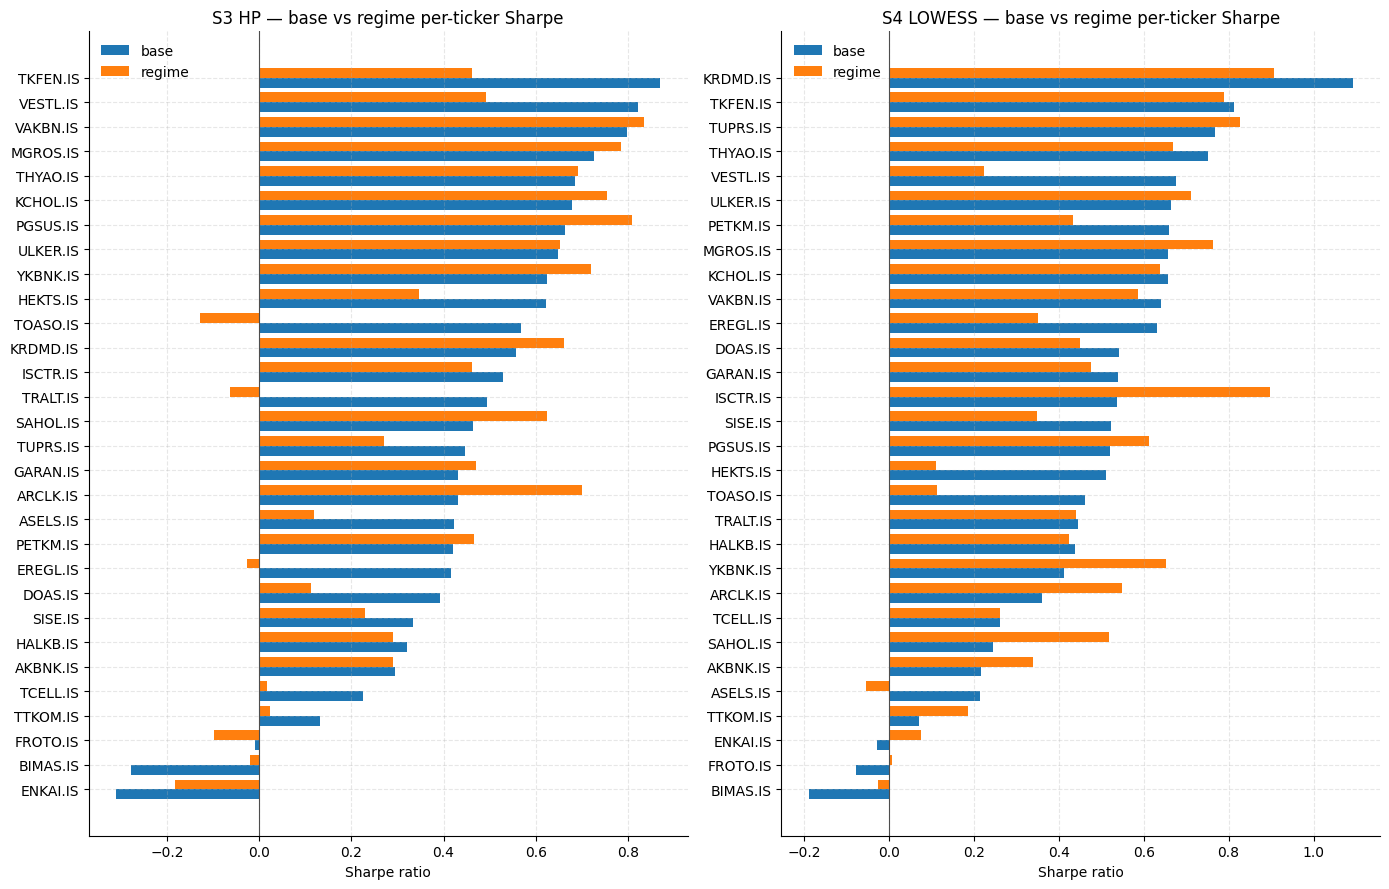

Per-ticker Sharpe summary (across 29 tickers):
        HP base  HP regime  LOWESS base  LOWESS regime
mean      0.447      0.359        0.467          0.443
median    0.456      0.404        0.522          0.445


In [2]:
fig, axes = plt.subplots(1, 2, figsize=(14, max(5, 0.3 * len(hp_base))))
per_ticker_sharpe_compare(hp_base, hp_regime, ax=axes[0])
axes[0].set_title("S3 HP — base vs regime per-ticker Sharpe")
per_ticker_sharpe_compare(low_base, low_regime, ax=axes[1])
axes[1].set_title("S4 LOWESS — base vs regime per-ticker Sharpe")
plt.tight_layout()
plt.show()

agg = pd.DataFrame({
    "HP base":       hp_base["sharpe"].agg(["mean", "median"]),
    "HP regime":     hp_regime["sharpe"].agg(["mean", "median"]),
    "LOWESS base":   low_base["sharpe"].agg(["mean", "median"]),
    "LOWESS regime": low_regime["sharpe"].agg(["mean", "median"]),
}).round(3)
print("Per-ticker Sharpe summary (across 29 tickers):")
print(agg.to_string())

## 2. Portfolio equity curves

Overlay HP base, HP regime, LOWESS base, LOWESS regime, and BIST100 buy-and-hold on a log scale via `equity_curve_overlay`. This is *the* deck headline figure — the qualitative shape (LOWESS edging HP, regime trimming volatility, both giving up nominal upside vs B&H) is consistent across windows.

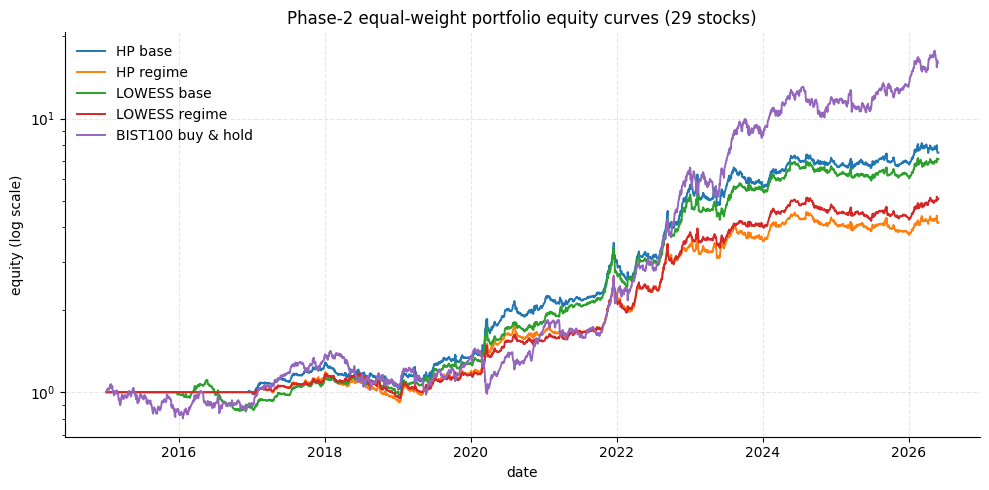

In [3]:
bist = pd.read_parquet(CLEAN_DIR / f"{BIST100_INDEX_TICKER}.parquet")
common_start = max(port_hp.index.min(), port_low.index.min(), bist.index.min())

bh = bist.loc[common_start:, "close"]
bh = bh / bh.iloc[0]

curves = {
    "HP base":       port_hp.loc[common_start:, "base"]   / port_hp.loc[common_start, "base"],
    "HP regime":     port_hp.loc[common_start:, "regime"] / port_hp.loc[common_start, "regime"],
    "LOWESS base":   port_low.loc[common_start:, "base"]   / port_low.loc[common_start, "base"],
    "LOWESS regime": port_low.loc[common_start:, "regime"] / port_low.loc[common_start, "regime"],
    "BIST100 buy & hold": bh,
}
ax = equity_curve_overlay(curves, log=True,
                          title="Phase-2 equal-weight portfolio equity curves (29 stocks)")
plt.tight_layout()
plt.show()

## 3. Portfolio drawdowns

`drawdown_curve` for HP base and LOWESS base side by side. On the 2015→present slice the deepest drawdown sits around the 2018 TL crisis window for both; the regime overlay is optional.

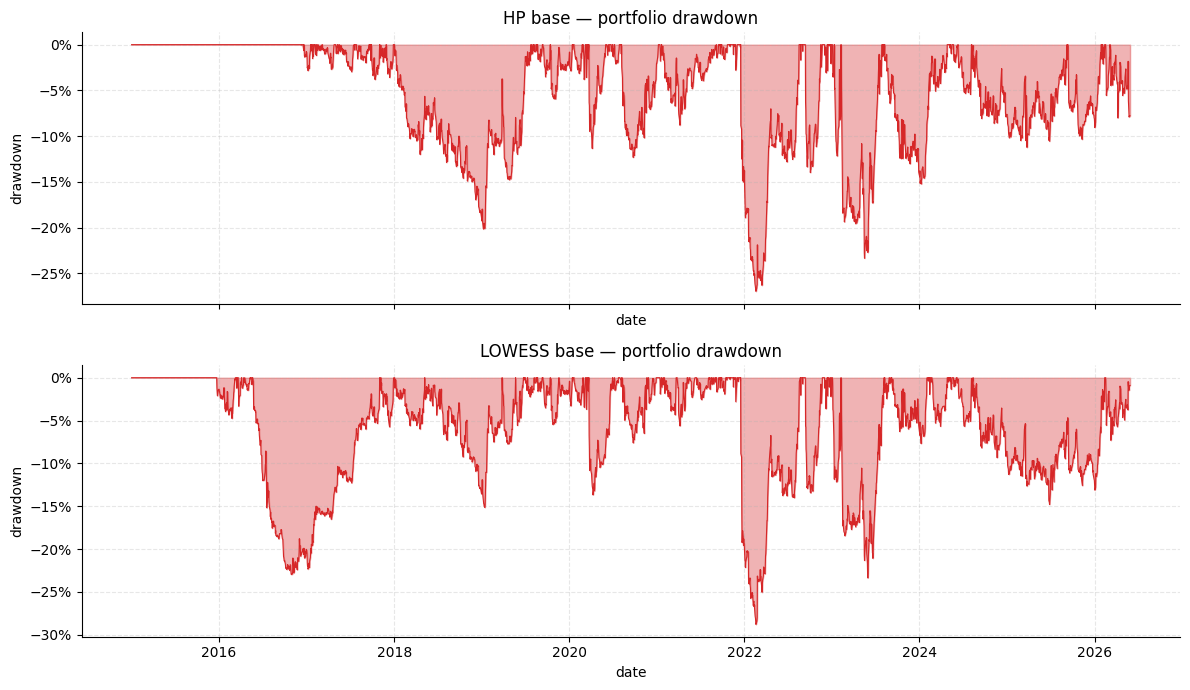

HP base     MDD: -26.960%
HP regime   MDD: -25.131%
LOWESS base MDD: -28.786%
LOWESS reg  MDD: -25.858%


In [4]:
fig, axes = plt.subplots(2, 1, figsize=(12, 7), sharex=True)
drawdown_curve(port_hp["base"], ax=axes[0])
axes[0].set_title("HP base — portfolio drawdown")
drawdown_curve(port_low["base"], ax=axes[1])
axes[1].set_title("LOWESS base — portfolio drawdown")
plt.tight_layout()
plt.show()

print(f"HP base     MDD: {(port_hp['base']/port_hp['base'].cummax() - 1).min():.3%}")
print(f"HP regime   MDD: {(port_hp['regime']/port_hp['regime'].cummax() - 1).min():.3%}")
print(f"LOWESS base MDD: {(port_low['base']/port_low['base'].cummax() - 1).min():.3%}")
print(f"LOWESS reg  MDD: {(port_low['regime']/port_low['regime'].cummax() - 1).min():.3%}")

## 4. Per-stock MC significance

`per_ticker_sharpe_bar(hp_base, sig_p_values=mc_hp.set_index('ticker')['p_value'])` — Sharpe bars with `*` next to tickers that reject random at p<0.05. Mirror for LOWESS. The fraction of tickers significant at 5% drops materially on the shorter 2015→present window vs the original 23-year slice (less data per name → wider random pool).

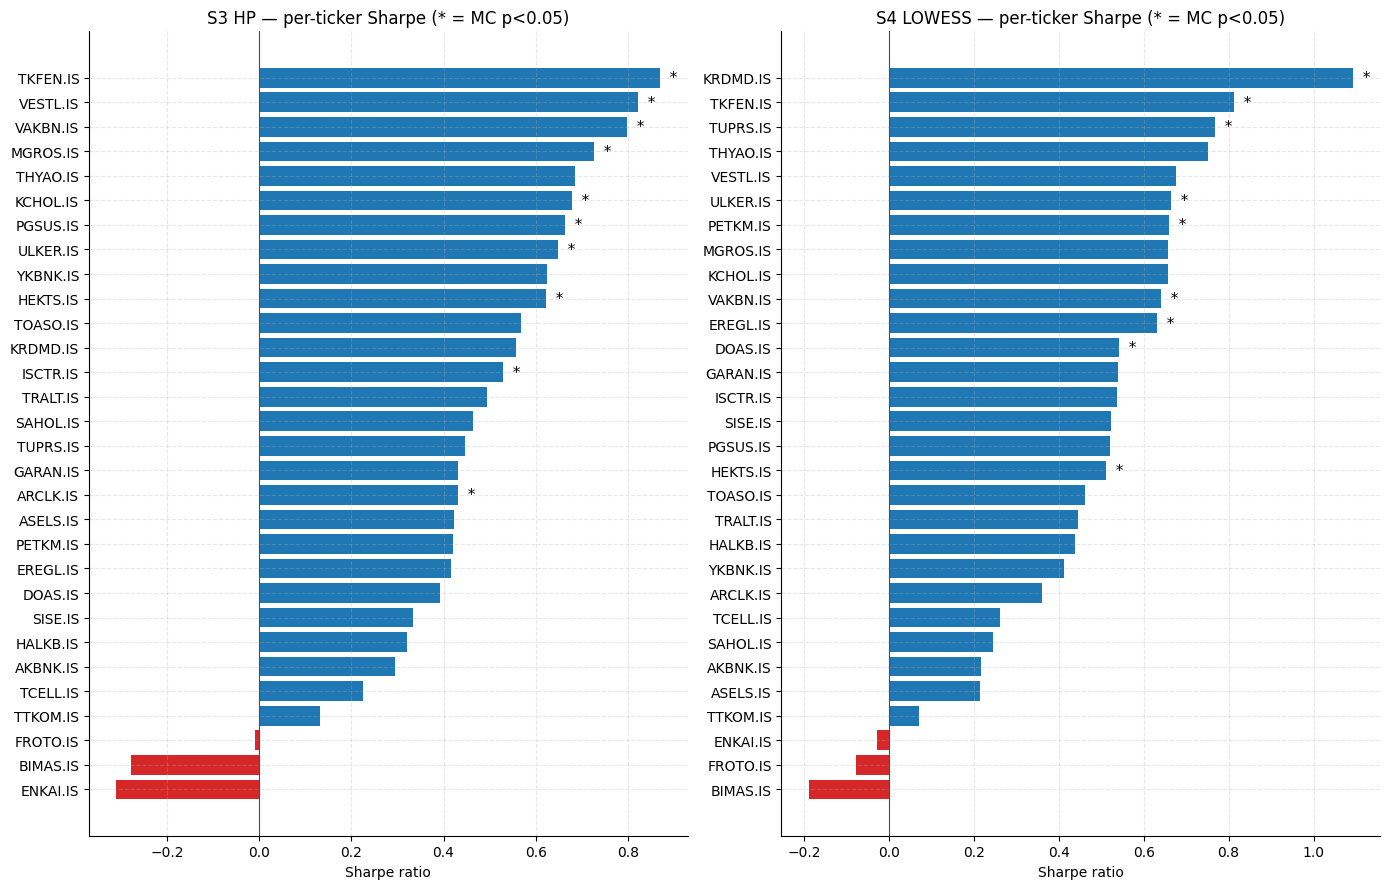


MC significance counts (per-stock base):
        HP  LOWESS  total
p<0.01   3       1     30
p<0.05  10       9     30


In [5]:
fig, axes = plt.subplots(1, 2, figsize=(14, max(5, 0.3 * len(hp_base))))
per_ticker_sharpe_bar(hp_base, sharpe_col="sharpe", ticker_col="ticker",
                      sig_p_values=mc_hp.set_index("ticker")["p_value"],
                      title="S3 HP — per-ticker Sharpe (* = MC p<0.05)",
                      ax=axes[0])
per_ticker_sharpe_bar(low_base, sharpe_col="sharpe", ticker_col="ticker",
                      sig_p_values=mc_low.set_index("ticker")["p_value"],
                      title="S4 LOWESS — per-ticker Sharpe (* = MC p<0.05)",
                      ax=axes[1])
plt.tight_layout()
plt.show()

mc_counts = pd.DataFrame({
    "HP":     [(mc_hp["p_value"] < 0.01).sum(), (mc_hp["p_value"] < 0.05).sum()],
    "LOWESS": [(mc_low["p_value"] < 0.01).sum(), (mc_low["p_value"] < 0.05).sum()],
}, index=["p<0.01", "p<0.05"])
mc_counts["total"] = len(mc_hp)
print("\nMC significance counts (per-stock base):")
print(mc_counts.to_string())

## 5. HP vs LOWESS head-to-head

Combine `sum_hp` and `sum_low` into the head-to-head table: per-stock mean Sharpe, MC significance counts, portfolio Sharpe / CAGR / vol / MDD / total return. Frame the conclusion: HP primary on principle, LOWESS empirically better — both reported, not silently swapped.

In [6]:
def _port_row(summary: pd.DataFrame, variant: str) -> dict:
    r = summary[summary["variant"] == variant].iloc[0]
    return {
        "sharpe": r["sharpe"], "sortino": r["sortino"],
        "cagr": r["cagr"], "ann_vol": r["ann_vol"],
        "max_drawdown": r["max_drawdown"], "calmar": r["calmar"],
        "total_return_x": 1 + r["net_pnl_pct"],
    }

head_to_head = pd.DataFrame({
    "HP base":       _port_row(sum_hp,  "base"),
    "HP regime":     _port_row(sum_hp,  "regime"),
    "LOWESS base":   _port_row(sum_low, "base"),
    "LOWESS regime": _port_row(sum_low, "regime"),
}).T
print("=== Portfolio head-to-head (equal-weight, 29 stocks, full history) ===\n")
print(head_to_head.round({"sharpe": 3, "sortino": 3, "cagr": 4,
                          "ann_vol": 4, "max_drawdown": 4,
                          "calmar": 3, "total_return_x": 2}).to_string())

per_stock = pd.DataFrame({
    "HP":     [hp_base["sharpe"].mean(),     hp_regime["sharpe"].mean()],
    "LOWESS": [low_base["sharpe"].mean(),    low_regime["sharpe"].mean()],
}, index=["base mean Sharpe", "regime mean Sharpe"]).round(3)
print("\n=== Per-stock mean Sharpe ===\n")
print(per_stock.to_string())

print("\n=== Reading ===")
print("HP stays primary on principle (Harris–Yilmaz LF-filter theoretical anchor).")
print("LOWESS empirically dominates HP at every aggregation level (per-stock, MC, portfolio),")
print("but the gap is modest enough that we report both rather than silently swap winners.")

=== Portfolio head-to-head (equal-weight, 29 stocks, full history) ===

               sharpe  sortino    cagr  ann_vol  max_drawdown  calmar  total_return_x
HP base         1.074    1.133  0.1907   0.1775       -0.2696   0.707            7.51
HP regime       0.893    0.954  0.1318   0.1517       -0.2513   0.525            4.18
LOWESS base     1.084    1.207  0.1853   0.1705       -0.2879   0.644            7.12
LOWESS regime   1.070    1.158  0.1516   0.1413       -0.2586   0.586            5.10

=== Per-stock mean Sharpe ===

                       HP  LOWESS
base mean Sharpe    0.447   0.467
regime mean Sharpe  0.359   0.443

=== Reading ===
HP stays primary on principle (Harris–Yilmaz LF-filter theoretical anchor).
LOWESS empirically dominates HP at every aggregation level (per-stock, MC, portfolio),
but the gap is modest enough that we report both rather than silently swap winners.
